<a href="https://colab.research.google.com/github/chen911119/Homework/blob/HW1/HW1_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch torchvision --quiet

In [3]:
import torch
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import torch.nn.functional as F

transform= transforms.ToTensor()
train_dataset= MNIST(root= './data', train= True, download= True, transform= transform)
test_dataset= MNIST(root= './data', train= False, download= True, transform= transform)

train_loader= DataLoader(train_dataset, batch_size= 128, shuffle= True)
test_loader= DataLoader(test_dataset, batch_size= 128, shuffle= False)

class VAE(nn.Module):
  def __init__(self):
    super(VAE, self).__init__()

    self.fc1= nn.Linear(784, 400)
    self.fc_mu= nn.Linear(400, 20)
    self.fc_logvar = nn.Linear(400, 20)

    self.fc3 = nn.Linear(20, 400)
    self.fc4 = nn.Linear(400, 784)
  def encode(self, x):
    h1 = F.relu(self.fc1(x))
    mu = self.fc_mu(h1)
    logvar = self.fc_logvar(h1)
    return mu, logvar

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z):
    h3 = F.relu(self.fc3(z))
    return torch.sigmoid(self.fc4(h3))

  def forward(self, x):
    mu, logvar = self.encode(x.view(-1, 784))
    z = self.reparameterize(mu, logvar)
    return self.decode(z), mu, logvar

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.77MB/s]


In [4]:
def loss_function(recon_x, x, mu, logvar):
  BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
  KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return BCE + KLD

In [5]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train(epoch):
  model.train()
  train_loss = 0
  for batch_idx, (data, _) in enumerate(train_loader):
    data = data.to(device)
    optimizer.zero_grad()
    recon_batch, mu, logvar = model(data)
    loss = loss_function(recon_batch, data, mu, logvar)
    loss.backward()
    train_loss += loss.item()
    optimizer.step()
  average_loss = train_loss / len(train_loader.dataset)
  print(f'Epoch {epoch}, Average loss: {average_loss:.4f}')

Epoch 1, Average loss: 119.1177
Epoch 2, Average loss: 113.6459
Epoch 3, Average loss: 111.0354
Epoch 4, Average loss: 109.4572
Epoch 5, Average loss: 108.3293


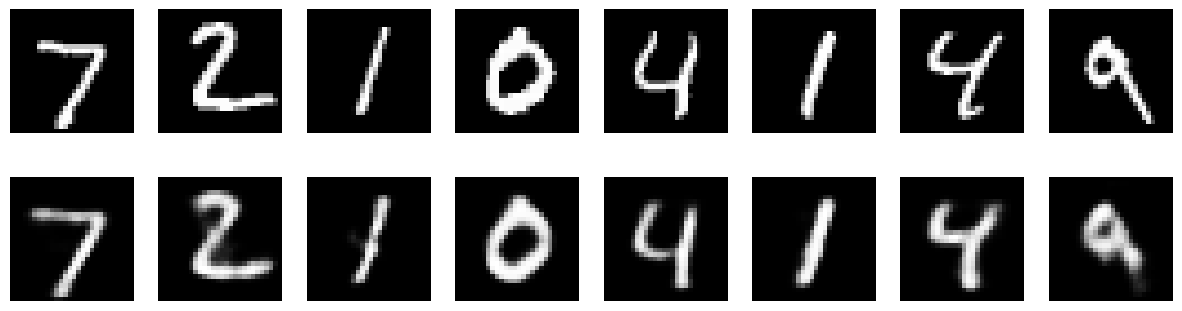

<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt

def show_reconstructed_images(x, recon_x, num_images=8):
  x = x.view(-1, 784).cpu().data
  recon_x = recon_x.view(-1, 784).cpu().data
  plt.figure(figsize=(15, 4))
  for i in range(num_images):
    # 原始影像
    plt.subplot(2, num_images, i + 1)
    plt.imshow(x[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    # 重建影像
    plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(recon_x[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
  plt.show()

# 訓練多個epoch並展示部分重建結果
num_epochs = 5
for epoch in range(1, num_epochs + 1):
  train(epoch)

# 訓練 all epochs 結束後再取一批 test，產生結果圖
model.eval()
with torch.no_grad():
  test_batch = next(iter(test_loader))[0].to(device)
  recon_batch, _, _ = model(test_batch)
show_reconstructed_images(test_batch, recon_batch)
plt.savefig('reconstruction.png')  # 可加這行存檔